# Hierarchical binary inference across filters

Here we fit three interferometric observations simultaneously. The binary position is shared between filters, while each filter has its own flux ratio. We also distinguish the expected Fisher information used to scale the optimization from the observed likelihood curvature used for a local Laplace uncertainty estimate.

In [ ]:
import sys
from pathlib import Path

import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax.flatten_util import ravel_pytree

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
for path in (repo_root, repo_root / "src"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from drpangloss.inference import fisher_projection, gaussian_fisher
from drpangloss.models import (
    BinaryModelCartesian,
    joint_loglike,
    joint_prediction,
)
from examples.hierarchical_binary_workflow import (
    FILTER_LABELS,
    binary_model,
    observation_errors,
    run_hierarchical_binary_demo,
    simulate_observations,
)

## Simulate three observations

The three `OIData` objects have the same baseline sampling and uncertainties but wavelengths of 800 nm, 1.0 micron, and 1.2 microns. `OIData.with_model` preserves that observing configuration while replacing the observables with a model realization and optional Gaussian noise.

In [2]:
observations, truth = simulate_observations(seed=7)

{
    label: {
        "wavelength_m": float(observation.wavel[0]),
        "n_observables": int(observation.flatten_data()[0].size),
        "flux_ratio": float(10.0 ** truth["log10_flux"][index]),
    }
    for index, (label, observation) in enumerate(
        zip(FILTER_LABELS, observations)
    )
}

W0919 16:38:54.464285  440271 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


{'800 nm': {'wavelength_m': 8e-07,
  'n_observables': 36,
  'flux_ratio': 0.014999999999999996},
 '1.0 micron': {'wavelength_m': 1e-06,
  'n_observables': 36,
  'flux_ratio': 0.010000000000000005},
 '1.2 microns': {'wavelength_m': 1.2e-06,
  'n_observables': 36,
  'flux_ratio': 0.007000000000000002}}

## Define the hierarchy

The hierarchy is expressed by an ordinary JAX pytree. The scalar astrometry is shared, while indexing the flux vector selects a parameter unique to each observation. This is the same model-building pattern used by Zodiax: parameters remain separate from the objects that describe each observation.

In [3]:
params = {
    "dra": jnp.array(15.0),
    "ddec": jnp.array(-9.0),
    "log10_flux": jnp.log10(jnp.array([0.012, 0.012, 0.012])),
}


def model_fn(values, observation_index):
    return BinaryModelCartesian(
        values["dra"],
        values["ddec"],
        10.0 ** values["log10_flux"][observation_index],
    )


initial_loglike = joint_loglike(params, observations, model_fn)
truth_loglike = joint_loglike(truth, observations, model_fn)
{
    "initial_loglike": float(initial_loglike),
    "truth_loglike": float(truth_loglike),
}

{'initial_loglike': -6385.33425087397, 'truth_loglike': -48.91251621611459}

## Construct the expected Fisher information

For fixed independent Gaussian errors, the expected Fisher information is exactly $F = J^T W J$, even when the prediction is nonlinear in the parameters. It is positive semidefinite and independent of the particular noise realization, making it useful for whitening the optimization coordinates.

In [4]:
prediction_fn = lambda values: joint_prediction(
    values, observations, binary_model
)
errors = observation_errors(observations)
initial_fisher, unravel = gaussian_fisher(
    prediction_fn, params, errors, ridge=1e-8
)
projection = fisher_projection(initial_fisher, eps=1e-10)

{
    "fisher_shape": initial_fisher.shape,
    "whitened_metric": projection.T @ initial_fisher @ projection,
}

{'fisher_shape': (5, 5),
 'whitened_metric': Array([[ 1.00000000e+00, -1.27301457e-14,  2.65879295e-15,
         -8.28795953e-15, -1.63882087e-15],
        [-1.27803055e-14,  1.00000000e+00, -1.38036846e-16,
          2.59037282e-16,  1.90507011e-16],
        [ 2.57401550e-15, -2.15819231e-16,  1.00000000e+00,
         -6.67937215e-17, -1.67082727e-16],
        [-8.30188663e-15,  2.39350635e-16, -6.68363146e-17,
          1.00000000e+00, -8.98250567e-17],
        [-1.65031501e-15,  1.92294384e-16, -1.67144588e-16,
         -8.98142407e-17,  1.00000000e+00]], dtype=float64)}

## Fit in Fisher-whitened coordinates

Following the Zodiax optimization tutorial, we optimize a zero-centered latent vector and project it back into the physical parameter pytree. The helper uses Optimistix BFGS and the Fisher projection calculated at the initial point.

In [5]:
summary = run_hierarchical_binary_demo(seed=7)

recovered_flux = 10.0 ** summary.recovered["log10_flux"]
truth_flux = 10.0 ** summary.truth["log10_flux"]
{
    "initial_reduced_chi2": summary.initial_chi2r,
    "final_reduced_chi2": summary.final_chi2r,
    "truth_dra_mas": float(summary.truth["dra"]),
    "recovered_dra_mas": float(summary.recovered["dra"]),
    "truth_ddec_mas": float(summary.truth["ddec"]),
    "recovered_ddec_mas": float(summary.recovered["ddec"]),
    "truth_fluxes": truth_flux,
    "recovered_fluxes": recovered_flux,
}

{'initial_reduced_chi2': 123.9870728325043,
 'final_reduced_chi2': 0.8943819615350423,
 'truth_dra_mas': 18.0,
 'recovered_dra_mas': 17.96212282578262,
 'truth_ddec_mas': -12.0,
 'recovered_ddec_mas': -11.928193565383811,
 'truth_fluxes': Array([0.015, 0.01 , 0.007], dtype=float64),
 'recovered_fluxes': Array([0.01491984, 0.01003515, 0.00700039], dtype=float64)}

## Expected and observed curvature

The observed information is the Hessian of the negative log likelihood for this particular dataset. It contains a residual-weighted model-curvature term that is absent from the expected Fisher information. We use the observed information at the fitted solution for the local Laplace covariance.

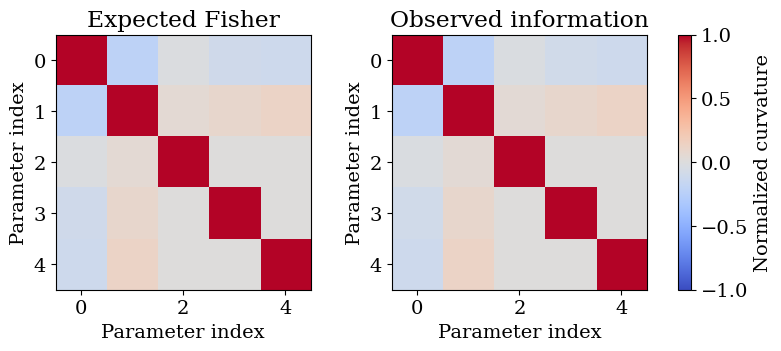

In [6]:
def correlation(matrix):
    scale = jnp.sqrt(jnp.abs(jnp.diag(matrix)))
    return matrix / jnp.outer(scale, scale)


fig, axes = plt.subplots(1, 2, figsize=(8, 3.4), constrained_layout=True)
for ax, matrix, title in zip(
    axes,
    (summary.expected_fisher, summary.observed_information),
    ("Expected Fisher", "Observed information"),
):
    image = ax.imshow(correlation(matrix), vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title(title)
    ax.set_xlabel("Parameter index")
    ax.set_ylabel("Parameter index")
fig.colorbar(image, ax=axes, label="Normalized curvature")
plt.show()

In [7]:
flat_recovered, _ = ravel_pytree(summary.recovered)
parameter_names = [
    "ddec (mas)",
    "dra (mas)",
    "log10 flux: 800 nm",
    "log10 flux: 1.0 micron",
    "log10 flux: 1.2 microns",
]
laplace_sigma = jnp.sqrt(jnp.diag(summary.laplace_covariance))
{
    name: {"estimate": float(value), "laplace_sigma": float(sigma)}
    for name, value, sigma in zip(
        parameter_names, flat_recovered, laplace_sigma
    )
}

{'ddec (mas)': {'estimate': -11.928193565383811,
  'laplace_sigma': 0.048961508424356745},
 'dra (mas)': {'estimate': 17.96212282578262,
  'laplace_sigma': 0.04878174841724983},
 'log10 flux: 800 nm': {'estimate': -1.8262356970862887,
  'laplace_sigma': 0.001677751652555576},
 'log10 flux: 1.0 micron': {'estimate': -1.9984762187934384,
  'laplace_sigma': 0.002589982668792857},
 'log10 flux: 1.2 microns': {'estimate': -2.154877810613793,
  'laplace_sigma': 0.004064131977928648}}

## Corner plot of shared and per-filter parameters

We have not run HMC in this tutorial, but we can still visualize the local uncertainty with a corner plot by drawing Gaussian samples from the Laplace covariance around the recovered solution, following the same `chainconsumer` helpers used in the binary search tutorial. The five parameters are the shared astrometry `dra`/`ddec` and one `log10_flux` per filter.

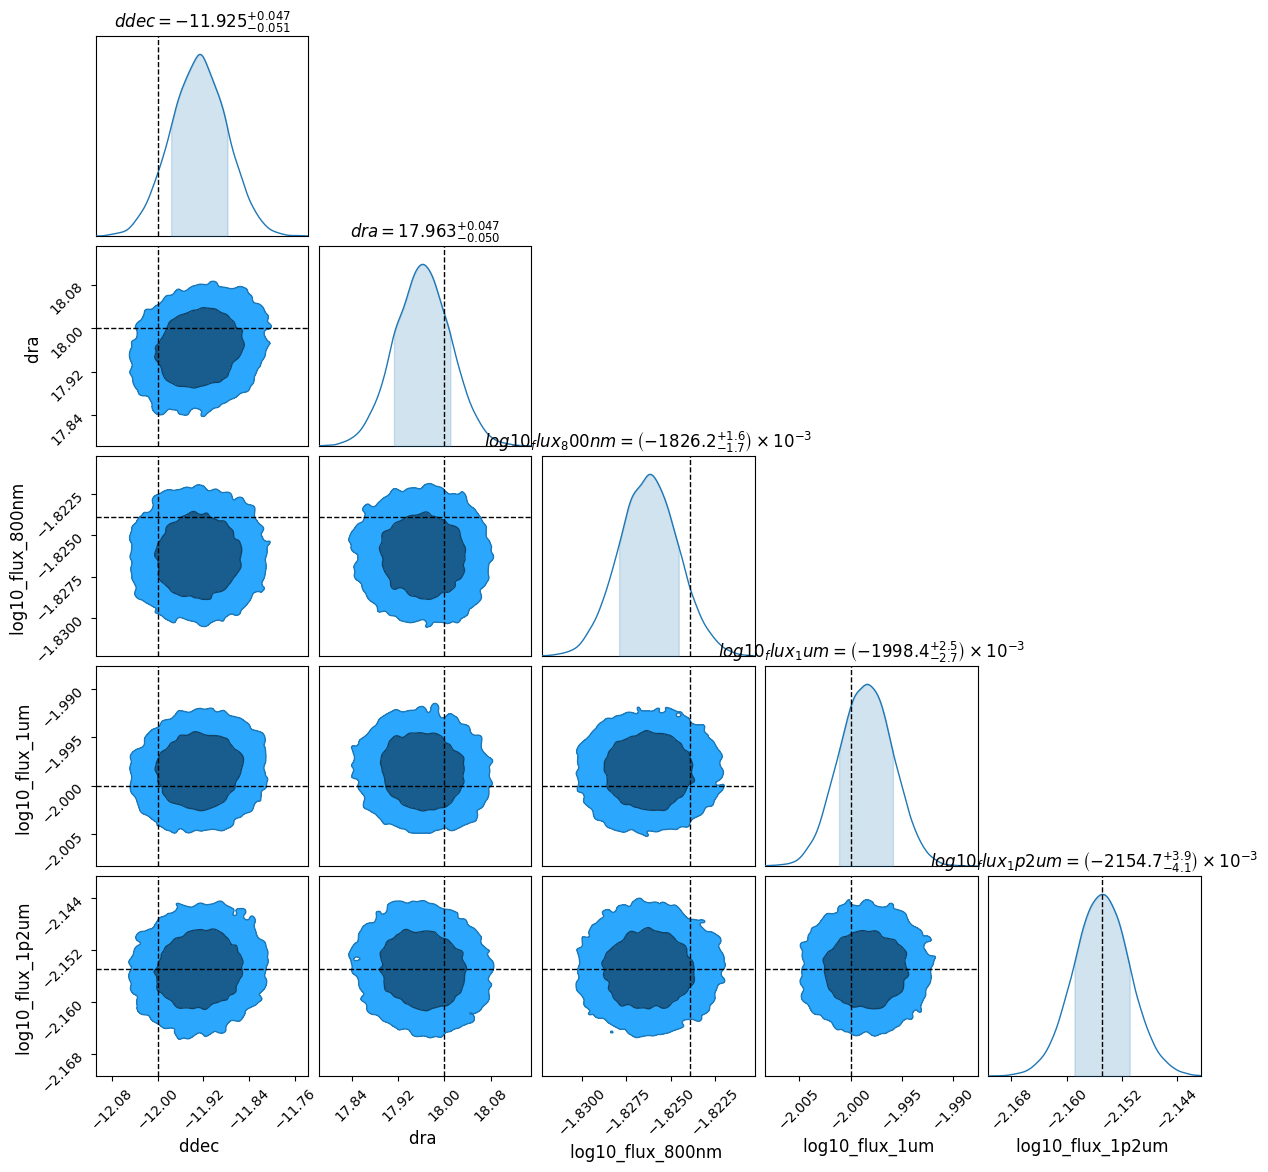

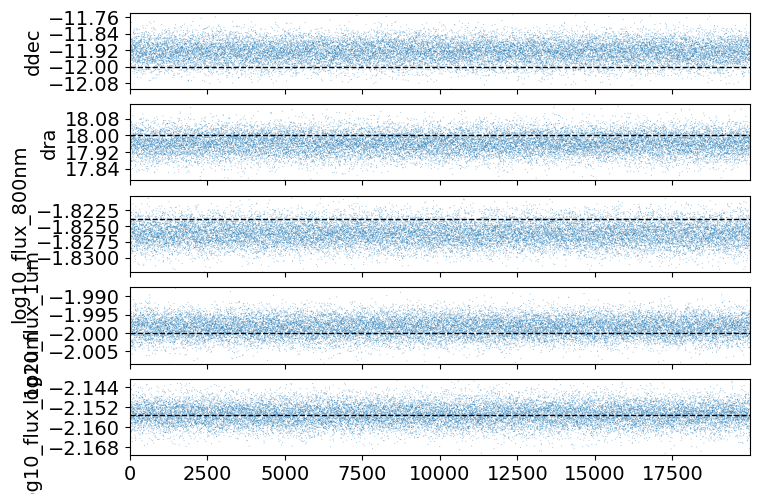

In [8]:
import numpy as onp
import pandas as pd

from drpangloss.plotting import (
    plot_chainconsumer_diagnostics,
    plot_data_model_correlation,
    posterior_predictive_summary,
)

parameter_columns = [
    "ddec",
    "dra",
    "log10_flux_800nm",
    "log10_flux_1um",
    "log10_flux_1p2um",
]

flat_recovered, unravel_recovered = ravel_pytree(summary.recovered)
flat_truth, _ = ravel_pytree(summary.truth)

# Gaussian samples from the local Laplace covariance around the fitted solution.
n_samples = 20000
cholesky = jnp.linalg.cholesky(summary.laplace_covariance)
standard_normal = jax.random.normal(
    jax.random.key(11), (n_samples, flat_recovered.size)
)
latent_samples = flat_recovered[None, :] + standard_normal @ cholesky.T

samples_df = pd.DataFrame(
    onp.asarray(latent_samples), columns=parameter_columns
)
truth_dict = dict(zip(parameter_columns, onp.asarray(flat_truth)))

plot_chainconsumer_diagnostics(
    {"Laplace approximation": samples_df},
    columns=parameter_columns,
    truth=truth_dict,
    colors=["#1f77b4"],
);

## Posterior predictive correlation per filter

As always, we check the fit against the data directly rather than trusting the corner plot alone. Each filter has its own flux, so we build one data-vs-model correlation plot per observation using the shared astrometry samples paired with that filter's flux samples.

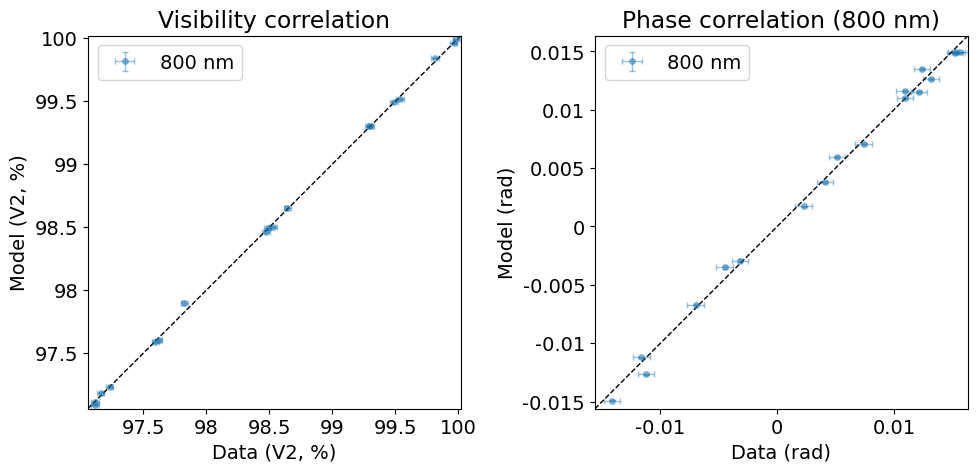

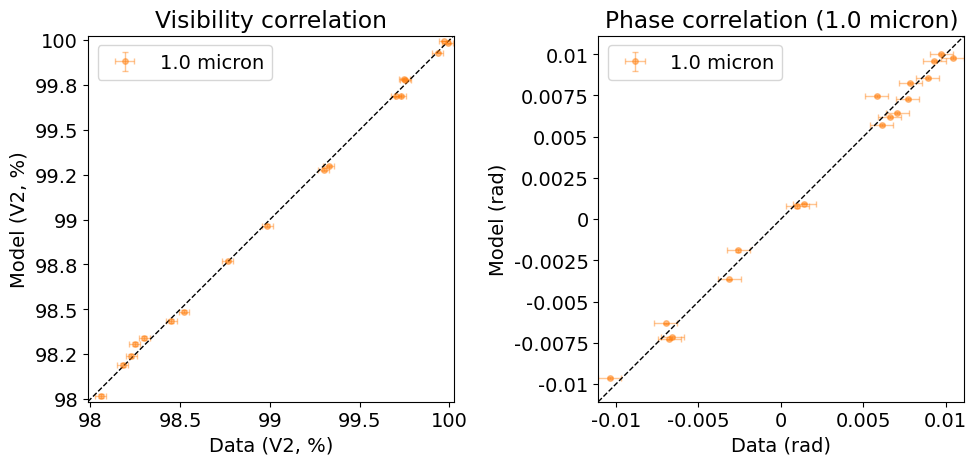

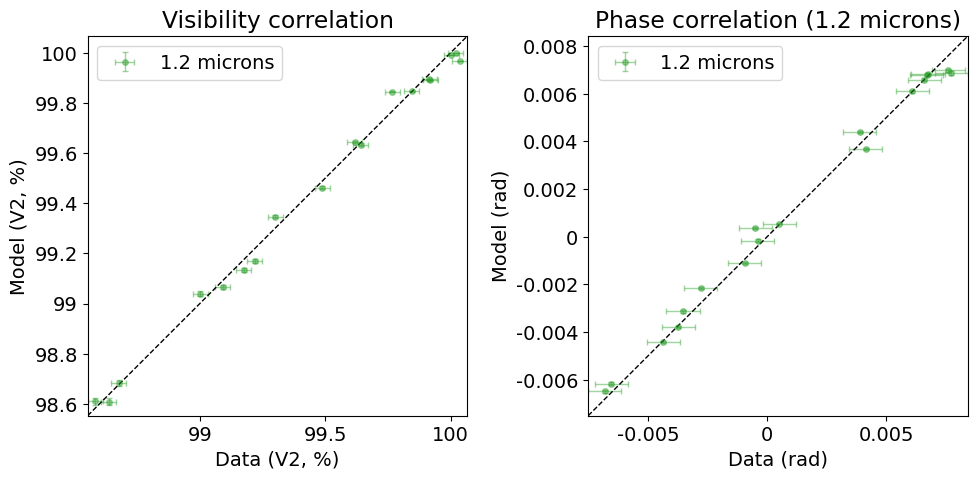

In [9]:
# Subsample the Laplace draws for the (slower, per-sample) posterior predictive check.
predictive_samples = jax.vmap(unravel_recovered)(latent_samples[:500])

for index, (label, observation) in enumerate(zip(FILTER_LABELS, observations)):
    predicted = posterior_predictive_summary(
        onp.asarray(predictive_samples["dra"]),
        onp.asarray(predictive_samples["ddec"]),
        onp.asarray(10.0 ** predictive_samples["log10_flux"][:, index]),
        observation,
        BinaryModelCartesian,
    )
    plot_data_model_correlation(
        observation,
        {label: predicted},
        colors=[f"C{index}"],
        phase_title=f"Phase correlation ({label})",
    )
    plt.show()

## Visibility and phase versus baseline

Finally, we look at visibility amplitude and phase directly as a function of baseline length, one column per filter. Because the three observations share the same array geometry, the baseline lengths are identical; only the flux, and therefore the fitted amplitude and phase, differ between filters.

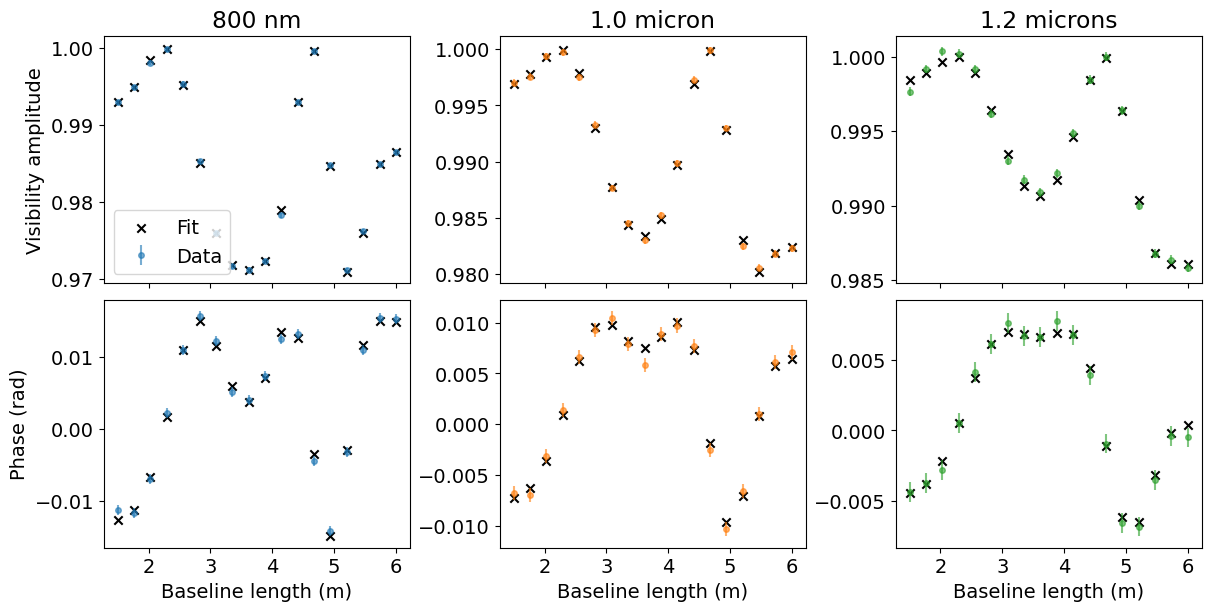

In [10]:
fig, axes = plt.subplots(
    2, 3, figsize=(12, 6), sharex=True, constrained_layout=True
)

for index, (label, observation) in enumerate(zip(FILTER_LABELS, observations)):
    baseline = jnp.sqrt(observation.u**2 + observation.v**2)
    cvis_fit = binary_model(summary.recovered, index).model(
        observation.u, observation.v, observation.wavel
    )
    vis_fit = observation.to_vis(cvis_fit)
    phi_fit = observation.to_phases(cvis_fit)

    ax_vis, ax_phi = axes[0, index], axes[1, index]
    ax_vis.errorbar(
        baseline,
        observation.vis,
        yerr=observation.d_vis,
        fmt="o",
        markersize=4,
        alpha=0.6,
        color=f"C{index}",
        label="Data",
    )
    ax_vis.scatter(baseline, vis_fit, marker="x", color="k", label="Fit")
    ax_vis.set_title(label)

    ax_phi.errorbar(
        baseline,
        observation.phi,
        yerr=observation.d_phi,
        fmt="o",
        markersize=4,
        alpha=0.6,
        color=f"C{index}",
    )
    ax_phi.scatter(baseline, phi_fit, marker="x", color="k")
    ax_phi.set_xlabel("Baseline length (m)")

axes[0, 0].set_ylabel("Visibility amplitude")
axes[1, 0].set_ylabel("Phase (rad)")
axes[0, 0].legend(loc="best")
plt.show()